A perceptron is a simple artificial neuron and one of the earliest machine-learning algorithms. It computes a weighted sum of input features, applies a threshold function, and produces a binary output. It can learn linearly separable classification problems.

It is the foundation unit of Deep Learning. A perceptron can be represented mathematically as follows: 

f(x) = 1, if w·x + b > 0; 0, otherwise

So, we can regard perceptron as classifier, which is the oldest AI unit, later, developed as a branch of machine learning, and then deep learning.



we can express how perceptron learns from data:
define input vector $\bf{x}$ and weight vector $\bf{w}$ as:
$$\mathbf{x} = 
\begin{bmatrix}
1 \\
x_1 \\
x_2 \\
\vdots \\
x_d
\end{bmatrix}
\mathbf{w} = 
\begin{bmatrix}
b \\
w_1 \\
w_2 \\
\vdots \\
w_d
\end{bmatrix}
$$
 
we can express the output of the perceptron as $y$, here $y\in\{0,1\}$ or $\{-1,1\}$ (used widely at old machine learning, as can be easily realted to vector changing). They have the property that: $y = f(\mathbf{w}^T \mathbf{x})$

where $f$ is the activation function, typically a step function for a perceptron. or use sign() function for the output $\{-1, 1\}$. Here we use step function as the activation function, which can be expressed as:

$$y = step(\mathbf{w}^T \mathbf{x})$$

The updating procedure is simple, we more care about the mechnism behind. 

1. Initialize the weights $\mathbf{w^{(0)}}$ and bias $b$ to small random values. Old machine learning often used zero initialization, but random initialization helps break symmetry and allows the model to learn better.
2. calculate the output $y$ for each input vector $\mathbf{x}$ using the current weights and bias. $$y^{(0)}_j=step(\mathbf{w^{(0)}}^T \mathbf{x_j})$$, we will always find the output $y_j$ is not equal to the target label $y(j)$ for some input vectors, which means the model is not perfect yet.
3. update the weights: we expect $y(j) = step(\mathbf{w^{(1)}}^T \mathbf{x_j})$, but now $y_j=step(\mathbf{w^{(0)}}^T \mathbf{x_j})$ is wrong, with the difference (error) as: $err = y(j) - y_j$, or can be written as $err = y(j) - step(\mathbf{w^{(0)}}^T \mathbf{x_j})$, and so $y(j) = step(\mathbf{w^{(0)}}^T \mathbf{x_j}) + err$. 
4. But we cannot update the weights directly, as we don't have the tool to unpackage 'step' function. However, luckily, $err = \delta(x-x_j)$ can be regard as a Delta function, and further can be choose as $\phi\cdot x_j$, which have $(w+\phi\cdot x_j)^T x_j = w^T x_j + \phi\cdot ||x_j||^2$, here $\phi$ is propotional to the $err$. We expect to update "Guess" value to "True" value within $N=1/\eta$ steps.
5. Update the weights using the error and a learning rate $\eta$:
$$\mathbf{w^{(1)}} = \mathbf{w^{(0)}} + \eta \cdot err \cdot \mathbf{x_j}$$

Repeat steps

But, in traditional ML, this can be visualize in a vector manner, wher $\mathbf{w}$ and $\mathbf{x}$ are vectors in a d-dimensional space. The perceptron learning algorithm adjusts the weight vector $\mathbf{w}$ in the direction of the input vector $\mathbf{x_j}$ when the prediction is incorrect. This adjustment moves the decision boundary closer to correctly classifying the input.

i.e.

$$y(j) = -1, y_j = 1$$

$x_j$ have a < 90 degree angle with $\mathbf{w^{(0)}}$, but we cannot directly flip the $w$, we can only rotate it to make angle larger than 90 degree. So we update $w^{(1)} = w^{(0)} + \eta\cdot y(j)\cdot x_j$

we can imaging if $\eta$ is very large, it directly change the $w$ to the $-$ direction of $x_j$ (the opposite for $y(j) = 1$), which is not good, as it may cause overfitting or oscillation. Therefore, a small learning rate $\eta$ is preferred to ensure gradual convergence.

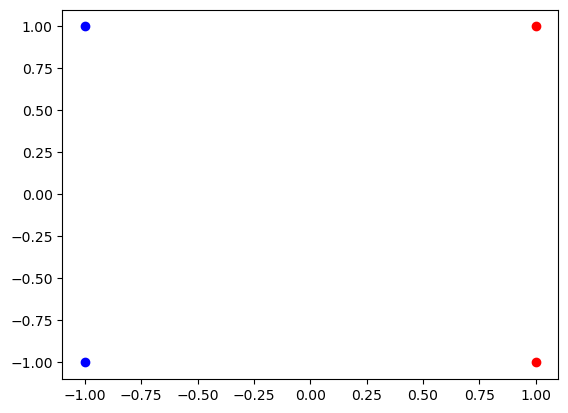

In [2]:
import matplotlib.pyplot as plt
import random    
p_1, y_1 = (1,1), 1
p_2, y_2 = (-1,-1), 0
p_3, y_3 = (1,-1), 1
p_4, y_4 = (-1,1), 0

dict_data = {p_1:y_1, p_2:y_2, p_3:y_3, p_4:y_4}
plt.plot((p_1[0], p_3[0]), (p_1[1], p_3[1]), 'ro')
plt.plot((p_4[0], p_2[0]), (p_4[1], p_2[1]), 'bo')

[1.2955608364337057, 2.30458461819154, 0.3210473604222221]


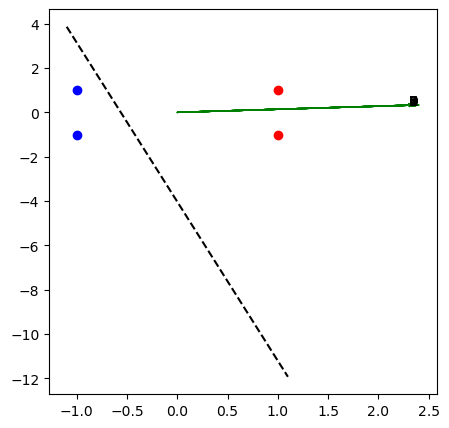

In [ ]:
w = [random.gauss(0, 1), random.gauss(0, 1), random.gauss(0, 1)];w
x = [1, 0, 0];x
eta = 0.5 # = 1 can make sure every time the w can be learned to the correct direction, but it may be too large to make the w oscillate around the correct direction, so we choose a smaller eta = 0.5
N = 10
plt.figure(figsize=(5,5))

plt.plot((p_1[0], p_3[0]), (p_1[1], p_3[1]), 'ro')
plt.plot((p_4[0], p_2[0]), (p_4[1], p_2[1]), 'bo')
for i in range(N):
    for point, label in dict_data.items():
        x[1], x[2] = point
        y_hat = 1 if (w[0]*x[0] + w[1]*x[1] + w[2]*x[2]) > 0 else 0
        if y_hat != label:
            w[0] += (label - y_hat) * x[0] * eta
            w[1] += (label - y_hat) * x[1] * eta
            w[2] += (label - y_hat) * x[2] * eta
    plt.arrow(0, 0, w[1], w[2], head_width=0.1, head_length=0.1, fc='g', ec='g')
    plt.text(w[1], w[2], f'{i}')
print(w)

# w0 + w1*x + w2*y = 0
slope = -w[1]/w[2]
intercept = -w[0]/w[2]

# range of x
x_line = [-1.1, -1, 0, 1, 1.1 ]
y_line = [slope * x + intercept for x in x_line]
plt.plot(x_line, y_line, 'k--', label='Decision Boundary')

You may noticed that,, not every time the $w$ can be learned to the correct direction, as the $x_j$ may not be in the right direction, but we can expect that after many iterations, the $w$ will converge to a good direction.

Next, we will show you non-seperable case, where the perceptron cannot converge to a good direction, and we will show you how to use deep learning to solve this problem.

[-0.1400823366113919, 0.7782979227082141, -0.7097177376575008]


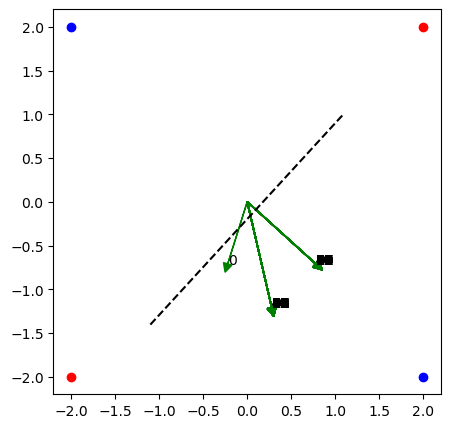

In [ ]:
p_5, y_5 = (2,2), 1 
p_6, y_6 = (-2,-2), 1
p_7, y_7 = (2,-2), 0
p_8, y_8 = (-2,2), 0

dict_data = {p_1:y_1, p_2:y_2, p_3:y_3, p_4:y_4, p_5:y_5, p_6:y_6, p_7:y_7, p_8:y_8}
plt.figure(figsize=(5,5))
plt.plot((p_5[0], p_6[0]), (p_5[1], p_6[1]), 'ro')
plt.plot((p_7[0], p_8[0]), (p_7[1], p_8[1]), 'bo')

w = [random.gauss(0, 1), random.gauss(0, 1), random.gauss(0, 1)];w
x = [1, 0, 0];x
eta = 0.5 # = 1 
N = 100 # here we use 100 iter

for i in range(N):
    for point, label in dict_data.items():
        x[1], x[2] = point
        y_hat = 1 if (w[0]*x[0] + w[1]*x[1] + w[2]*x[2]) > 0 else 0
        if y_hat != label:
            w[0] += (label - y_hat) * x[0] * eta
            w[1] += (label - y_hat) * x[1] * eta
            w[2] += (label - y_hat) * x[2] * eta
    plt.arrow(0, 0, w[1], w[2], head_width=0.1, head_length=0.1, fc='g', ec='g')
    plt.text(w[1], w[2], f'{i}')
print(w)

# w0 + w1*x + w2*y = 0
slope = -w[1]/w[2]
intercept = -w[0]/w[2]

# range of x
x_line = [-1.1, -1, 0, 1, 1.1 ]
y_line = [slope * x + intercept for x in x_line]
plt.plot(x_line, y_line, 'k--', label='Decision Boundary')

Normally, we need to add another layer to make the data separable, but the hand coding of 2-layer perceptron is a little bit tedious. Therefore, we can use deep learning to solve this problem.